# NOTES:

- To data loaded here was fromed by running:
> complie_RT_caltech_v1.m, complie_RT_caltech_v2.m, complie_RT_humburg.m, complie_RT_sydney.m, complie_RT_telaviv.m.
- Then:
> RT_concat_files.m


- There is more cleanup to do(!)
- Caltech2 had less trials, a 1/3 less. 16 instead of 24 for the 1-day and 96 instead of 144 in the 3-day group.

# Preparing stuff

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib import ticker
import plotly.graph_objects as go

import numpy as np
import pandas as pd
import seaborn as sns
import os
import math


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import learning_curve

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, auc, brier_score_loss, pairwise_distances, silhouette_samples, precision_score, recall_score, silhouette_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier # Multi layer perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay, partial_dependence
from sklearn.utils import shuffle
from sklearn.calibration import calibration_curve
from sklearn.tree import plot_tree
from sklearn.cross_decomposition import PLSRegression

import shap
from scipy.stats import binomtest, binom_test, ttest_ind, mannwhitneyu
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram

from joblib import Parallel, delayed
import pickle


from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression


# Functions

# LOAD DATA

In [2]:
# Load data from CSV
IPI_df = pd.read_csv('DATABASES/RT_ALL_SITES.csv')
run1_features_df = pd.read_csv('DATABASES/RUN1_FEATURES_ALL_SITES.csv')
Dependent_var_df_SCORE = pd.read_csv('DATABASES/DV_ALL_SITES.csv')
# Dependent_var_df_SCORE = pd.read_csv('DATABASES/CHANGE_means_clusters.csv')
Dependent_var_df_SCORE 


,oldSubID,newID,group,site,pre_val,pre_deval,post_val,post_deval,CHANGE_SCORE
0,1,51,1-day,Caltech1,4.877195,4.969821,5.729812,5.349233,0.473206
1,2,52,1-day,Caltech1,3.961162,4.079287,4.732055,4.593628,0.256552
2,3,53,1-day,Caltech1,1.628004,1.614908,1.749792,1.479064,0.257632
3,4,54,1-day,Caltech1,3.358101,4.113441,3.830604,2.874372,1.711572
4,5,55,1-day,Caltech1,1.128313,1.206503,0.700127,1.461566,-0.683249
...,...,...,...,...,...,...,...,...,...
301,237,364,3-day,Tel_Aviv,2.744744,2.426000,2.499009,3.238484,-1.058219
302,238,365,3-day,Tel_Aviv,0.951292,0.212646,0.000000,0.016673,-0.755319
303,239,366,3-day,Tel_Aviv,2.565446,2.626659,1.977234,0.216779,1.821668
304,240,367,3-day,Tel_Aviv,4.632651,4.500755,4.815051,5.081356,-0.398201


In [3]:
IPI_df.rename(columns={'newID': 'subID'}, inplace=True)
IPI_df['IPI'] = IPI_df.groupby(['subID', 'trial'])['RT'].diff()
IPI_df['IPI_abs_diff'] = IPI_df['IPI'].diff().abs()
# merge with DV
Dependent_var_df_SCORE.rename(columns={'newID': 'subID', 'CHANGE_SCORE': 'behav_adaptation_SCORE'}, inplace=True)
# Normalize (standardize) behav_adaptation_SCORE in Dependent_var_df_SCORE PER SITE(!):
Dependent_var_df_SCORE['behav_adaptation_SCORE_NORMED'] = Dependent_var_df_SCORE.groupby('site')['behav_adaptation_SCORE'].transform(
    lambda x: (x - x.mean()) / x.std()
)
# if not already merged:
if 'behav_adaptation_SCORE' not in IPI_df.columns:
    IPI_df = IPI_df.merge(Dependent_var_df_SCORE[['subID', 'behav_adaptation_SCORE', 'behav_adaptation_SCORE_NORMED']], on='subID', how='left')
IPI_df.head(20)
# save to CSV:
# IPI_df.to_csv('IPI_data_Pool_et_al.csv', index=False)
main_data_df = IPI_df.copy()

# Now prepare run1_features_df
run1_features_df.rename(columns={'newID': 'subID'}, inplace=True)
if 'behav_adaptation_SCORE_NORMED' not in run1_features_df.columns:
    run1_features_df = run1_features_df.merge(Dependent_var_df_SCORE[['subID', 'behav_adaptation_SCORE']], on='subID', how='left')

# remove the columns oldSubID,day,run if they exist:
for col in ['oldSubID', 'day', 'run']:
    if col in run1_features_df.columns:
        run1_features_df.drop(columns=[col], inplace=True)


run1_features_df

,subID,group,site,resp_rate_trial_mean,resp_rate_trial_std,resp_pairs_sum_std,RTs_first_resp_mean,RTs_first_resp_std,isCorrectResp_prop_mean,isCorrectResp_prop_std,...,resp_time_diff_std,volatility,right_vs_left,sweet_vs_salty,post_reward_RT_mean,post_reward_RT_std,resp_time_diff_after_reward_mean,resp_time_diff_after_reward_std,run_burstiness,behav_adaptation_SCORE
0,51,1-day,Caltech1,4.447937,0.772161,0.773119,1.196256,0.252079,0.993447,0.010024,...,0.136814,0.066667,188,-180,0.090504,0.086274,0.016819,0.100087,-0.214165,0.473206
1,52,1-day,Caltech1,4.044676,0.369296,0.428291,0.970590,0.479302,0.994602,0.008452,...,0.118758,0.068793,-20,-20,0.124221,0.110797,0.014837,0.054547,-0.341248,0.256552
2,53,1-day,Caltech1,1.564667,0.100611,0.089641,1.165038,0.201668,0.995760,0.010626,...,0.258177,0.147617,5,-5,0.248324,0.212158,-0.017729,0.610955,-0.409801,0.257632
3,54,1-day,Caltech1,4.031388,0.212653,0.311696,1.201565,1.021008,0.992700,0.011392,...,0.149887,0.074000,8,2,0.083272,0.035061,0.002787,0.065607,-0.222391,1.711572
4,55,1-day,Caltech1,0.936968,0.180706,0.311727,1.304098,0.398750,0.997807,0.007597,...,0.795475,0.600399,-10,12,0.912095,0.942819,0.962956,1.708348,-0.108216,-0.683249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,364,3-day,Tel_Aviv,2.765301,0.728363,1.285678,1.038404,0.339436,0.990743,0.015870,...,0.224215,0.148205,62,70,0.207068,0.224625,0.071628,0.299725,-0.229539,-1.058219
302,365,3-day,Tel_Aviv,3.534231,0.773736,1.413689,0.834004,0.271131,0.995653,0.006775,...,0.157825,0.085838,106,-110,0.096540,0.042246,0.008828,0.113908,-0.270029,-0.755319
303,366,3-day,Tel_Aviv,1.655246,0.184785,0.258539,1.965709,1.075888,0.995288,0.009051,...,0.237720,0.162923,45,47,0.234704,0.127724,-0.033121,0.203294,-0.405264,1.821668
304,367,3-day,Tel_Aviv,3.714765,0.371899,0.488428,1.268879,0.506702,0.995079,0.010164,...,0.126037,0.067802,-29,31,0.108934,0.066236,0.000826,0.061007,-0.342599,-0.398201


In [4]:
run1_features_df
# print the descriptive statistics of behav_adaptation_SCORE per site and group
run1_features_df.groupby(['site','group']).behav_adaptation_SCORE.describe()
# add a binary column 'isHabitual' based on behav_adaptation_SCORE lower than median:
run1_features_df['isHabitual'] = np.where(run1_features_df['behav_adaptation_SCORE'] <= run1_features_df.behav_adaptation_SCORE.median(), 1, 0)
run1_features_df.groupby(['site','group']).isHabitual.describe()

# Change group 1-day to -1 and 3-day to 1 for easier ML interpretation:
run1_features_df['group'] = run1_features_df['group'].map({'1-day': -1, '3-day': 1})
run1_features_df.groupby(['site', 'group']).isHabitual.describe()


count      mean       std  min  25%  50%  75%  max
site     group                                                    
Caltech1 -1      31.0  0.516129  0.508001  0.0  0.0  1.0  1.0  1.0
          1      31.0  0.548387  0.505879  0.0  0.0  1.0  1.0  1.0
Caltech2 -1      30.0  0.433333  0.504007  0.0  0.0  0.0  1.0  1.0
          1      29.0  0.586207  0.501230  0.0  0.0  1.0  1.0  1.0
Hamburg  -1      28.0  0.535714  0.507875  0.0  0.0  1.0  1.0  1.0
          1      37.0  0.540541  0.505228  0.0  0.0  1.0  1.0  1.0
Sydney   -1      30.0  0.366667  0.490133  0.0  0.0  0.0  1.0  1.0
          1      30.0  0.300000  0.466092  0.0  0.0  0.0  1.0  1.0
Tel_Aviv -1      30.0  0.600000  0.498273  0.0  0.0  1.0  1.0  1.0
          1      30.0  0.566667  0.504007  0.0  0.0  1.0  1.0  1.0

COntiniOUS !

Total n=306, mean=0.745, std=1.481, group_vals=[-1  1]

DATA SPLIT:
Training set (for LOOCV): n=244, mean=0.764, std=1.488
Held-out test set: n=62, mean=0.670, std=1.440

Stratification: Site + Group + Outcome

Training set:
  Groups: (array([-1,  1]), array([119, 125]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

Held-out test set:
  Groups: (array([-1,  1]), array([30, 32]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

RUNNING NESTED LOOCV ON TRAINING SET

n=244, mean=0.764, std=1.488, group_vals=[-1  1]
Total n=244, positive=186 (0.764), group_vals=[-1  1]


Outer CV folds: 100%|██████████| 244/244 [06:16<00:00,  1.55s/it]



NESTED LOOCV REGRESSION RESULTS:
R²: 0.0122
RMSE: 1.4791
MAE: 1.1025
Pearson r: 0.2166 (p=0.0007)
Spearman r: 0.1695 (p=0.0080)


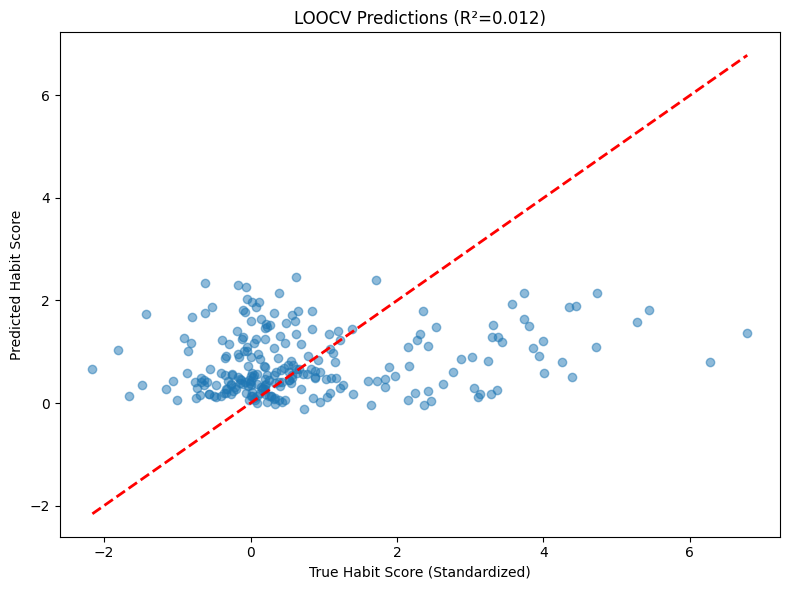


CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  RandomForest: 244/244 folds (100.0%)

Number of features selected:
  3 features: 157/244 folds (64.3%)
  5 features: 66/244 folds (27.0%)
  10 features: 21/244 folds (8.6%)

Most common configurations:
  RandomForest_nfeat3_max_depth5_min_samples_leaf10: 96/244 folds (39.3%)
  RandomForest_nfeat3_max_depth10_min_samples_leaf10: 61/244 folds (25.0%)
  RandomForest_nfeat5_max_depth5_min_samples_leaf10: 51/244 folds (20.9%)
  RandomForest_nfeat10_max_depth5_min_samples_leaf10: 18/244 folds (7.4%)
  RandomForest_nfeat5_max_depth10_min_samples_leaf10: 13/244 folds (5.3%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: RandomForest
Number of features: 3
Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 10}


In [ ]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression  # CHANGE THIS


features_data = run1_features_df.copy().reset_index(drop=True)
# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
y = block_df["behav_adaptation_SCORE"]
subjects = block_df["subID"].reset_index(drop=True)
sites = block_df["site"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)

drop_cols = {"subID", "group", "site", "behav_adaptation_SCORE", "isHabitual"}
X_cont = block_df.drop(columns=list(drop_cols))

# Convert to arrays FIRST (before splitting)
X_cont_arr_full = X_cont.values
y_arr_full = np.asarray(y).astype(float)  # Keep as float for regression
group_arr_full = group.values
subjects_arr_full = subjects.values
sites_arr_full = sites.values

print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}, group_vals={np.unique(group_arr_full)}")

# ============================================
# CREATE HELD-OUT TEST SET (20%)
# ============================================
# Stratify by site + group + outcome
y_binned = pd.qcut(y, q=3, labels=['T1', 'T2', 'T3'], duplicates='drop')
strat_labels = (sites.astype(str) + '_' + 
                group.astype(str) + '_' + 
                y_binned.astype(str))

train_idx, test_idx = train_test_split(
    np.arange(len(y_arr_full)),
    test_size=0.20,
    stratify=strat_labels,
    random_state=42
)

# ============================================
# TRAINING SET (for LOOCV nested CV)
# ============================================
X_cont_arr = X_cont_arr_full[train_idx]
# get the relevant df X_cont :
X_cont_main_tr_set = pd.DataFrame(X_cont_arr, columns=X_cont.columns)
y_arr = y_arr_full[train_idx]
subjects = pd.Series(subjects_arr_full[train_idx]).reset_index(drop=True)  # Convert back to Series for compatibility
group = pd.Series(group_arr_full[train_idx]).reset_index(drop=True)  # Convert back to Series for compatibility
group_arr = group.values

# ============================================
# HELD-OUT TEST SET (saved for final evaluation)
# ============================================
X_cont_arr_test_holdout = X_cont_arr_full[test_idx]
y_arr_test_holdout = y_arr_full[test_idx]
subjects_test_holdout = subjects_arr_full[test_idx]
group_arr_test_holdout = group_arr_full[test_idx]
sites_test_holdout = sites_arr_full[test_idx]

print(f"\n{'='*60}")
print(f"DATA SPLIT:")
print(f"{'='*60}")
print(f"Training set (for LOOCV): n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")
print(f"Held-out test set: n={len(y_arr_test_holdout)}, mean={y_arr_test_holdout.mean():.3f}, std={y_arr_test_holdout.std():.3f}")
print(f"\nStratification: Site + Group + Outcome")

# Check distributions
print(f"\nTraining set:")
print(f"  Groups: {np.unique(group_arr, return_counts=True)}")
print(f"  Sites: {np.unique(sites_arr_full[train_idx], return_counts=True)[0]}")

print(f"\nHeld-out test set:")
print(f"  Groups: {np.unique(group_arr_test_holdout, return_counts=True)}")
print(f"  Sites: {np.unique(sites_test_holdout, return_counts=True)[0]}")

# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")

print(f"n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}, group_vals={np.unique(group_arr)}")



# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    # 'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

models_to_test = {
    # 'LinearRegression': {'model': LinearRegression, 'params': {}},  # No regularization
    'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},  # Only true elastic net
    'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    'RandomForest': {'model': RandomForestRegressor, 'params':  {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"
measure_to_pick_model = "mse"  # or "mse"
measure_to_pick_model = "r2"  # or "mse"


# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
# n_features_to_test = ['all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")

# X_cont_arr
# y_arr
# subjects
# group
# group_arr


# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx, train_index, test_index, X_cont_arr, y_arr, group_arr, 
                        subjects, group_series, models_to_test, n_features_to_test, 
                        n_inner_folds, measure_to_pick_model):
    
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]
    group_train_Outer = group_arr[train_index]
    group_test_Outer = group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV - CHANGED to KFold for regression
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
    
    best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf  # CHANGED
    best_config = None
    
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_r2 = []
                inner_mse = []
                inner_mae = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):  # CHANGED: removed y stratification
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]
                    group_train_Inner = group_train_Outer[inner_train_idx]
                    group_test_Inner = group_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # # Feature selection
                    # n_features = X_cont_train_Inner_scaled.shape[1]
                    # if n_feat != "all" and n_feat < n_features:
                    #     selector = SelectKBest(f_regression, k=n_feat)
                    #     X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                    #     X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # # PCA
                    # if do_PCA:
                    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                    #     X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    #     X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    # else:
                    #     X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                    #     X_cont_test_Inner_pca = X_cont_test_Inner_scaled


                    # PCA on Inner TRAIN only (BEFORE SelectKBest)
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Feature selection (AFTER PCA)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)


                    # Add group
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression']:  # Add any other models without random_state
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate - CHANGED metrics
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_r2.append(r2_score(y_test_Inner, y_test_Inner_pred))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_test_Inner_pred))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_test_Inner_pred))
                
                # Average performance
                mean_inner_r2 = np.mean(inner_r2)
                mean_inner_mse = np.mean(inner_mse)
                mean_inner_mae = np.mean(inner_mae)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae
                }
                
                # Select best config - CHANGED
                if measure_to_pick_model == "r2" and mean_inner_r2 > best_inner_score:
                    best_inner_score = mean_inner_r2
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mse" and mean_inner_mse < best_inner_score:
                    best_inner_score = mean_inner_mse
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
    
    # Retrain on outer fold (same as before, but remove predict_proba calls)
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    
    # n_features_outer = X_cont_train_Outer_scaled.shape[1]
    # k_final = best_config["n_features"]
    # if k_final == "all" or k_final >= n_features_outer:
    #     X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    # else:
    #     selector_final = SelectKBest(f_regression, k=best_config['n_features'])
    #     X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
    #     X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    
    # if do_PCA:
    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
    #     X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    #     X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # else:
    #     X_cont_train_Outer_pca = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_pca = X_cont_test_Outer_scaled
        
    # PCA on Outer TRAIN only (BEFORE SelectKBest)
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled
    
    # Feature selection (AFTER PCA)
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_regression, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Counterfactuals
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, 
                                                np.where(group_counterfactual_test_Outer == 1, -1, 
                                                        group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
    
    # Train final model
    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    # Predict - REMOVED predict_proba
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    
    # Counterfactual predictions - REMOVED predict_proba
    y_pred_cf = model_final.predict(X_counterfactual_test_Outer)[0]
    y_pred_cf_x2 = model_final.predict(X_counterfactual_cf_x2_test_Outer)[0]

    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_counterfactual": y_pred_cf,
        "y_pred_counterfactual_x2": y_pred_cf_x2,
        "matching_sub": matching_sub,
        "matching_group": matching_group,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }
# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)
y_pred_counterfactual_all = np.array([r["y_pred_counterfactual"] for r in results], dtype=float)
y_pred_counterfactual_x2_all = np.array([r["y_pred_counterfactual_x2"] for r in results], dtype=float)

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')

# # ============================================
# # TRAIN FINAL MODEL ON ALL DATA
# # ============================================

# print(f'\n{"="*60}')
# print(f'Training final model on all data...')
# print(f'{"="*60}')

# # Get model class
# model_class = models_to_test[best_deployment_config['model_name']]['model']

# # Feature selection on all data
# if best_deployment_config['n_features'] < n_features:
#     selector_all = SelectKBest(f_classif, k=best_deployment_config['n_features'])
#     X_all_sel = selector_all.fit_transform(X, y)
#     selected_feature_indices = selector_all.get_support(indices=True)
#     selected_features = X.columns[selected_feature_indices]
#     print(f'Selected features: {list(selected_features)}')
# else:
#     X_all_sel = X.values
#     selected_features = X.columns
#     print(f'Using all features')

# # Train final model
# model_all = model_class(**best_deployment_config['params'], random_state=42)
# model_all.fit(X_all_sel, y)

# # Feature importance
# print(f'\nComputing feature importance...')
# feature_importance = permutation_importance(model_all, X_all_sel, y, n_repeats=100, random_state=42)

# # # ============================================
# # # RETURN RESULTS
# # # ============================================

# # results = {
# #     # Performance metrics
# #     'accuracy': accuracy,
# #     'auc_score': auc_score,
# #     'conf_matrix': conf_matrix,
# #     'fpr': fpr,
# #     'tpr': tpr,
# #     'thresholds': thresholds,
    
# #     # Predictions
# #     'y_true': y_true_all,
# #     'y_pred': y_pred_all,
# #     'y_pred_proba': y_pred_proba_all,
# #     'y_pred_proba_counterfactual': np.array(y_pred_proba_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual': np.array(y_pred_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_proba_counterfactual_x2': np.array(y_pred_proba_counterfactual_x2_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual_x2': np.array(y_pred_counterfactual_x2_all) if X_counterfactual is not None else None,
    
# #     # Metadata
# #     'matching_group': matching_group_all,
# #     'matching_sub': matching_sub_all,
    
# #     # Configuration info
# #     'selected_configs': selected_configs,
# #     'model_counts': model_counts,
# #     'nfeat_counts': nfeat_counts,
# #     'best_deployment_config': best_deployment_config,
    
# #     # Final model trained on all data
# #     'model_all': model_all,
# #     'feature_importance': feature_importance,
# #     'selected_features': selected_features,
# # }




# - Now with AUC
# aaaaaaaaaaaaaa



EVALUATING ON HELD-OUT TEST SET

Held-out test set results (n=62):
R²: 0.0387
RMSE: 1.4119
MAE: 1.0233
Pearson r: 0.2195 (p=0.0864)
Spearman r: 0.2936 (p=0.0206)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:109: RuntimeWarning: divide by zero encountered in divide
  msw = sswn / float(dfwn)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:109: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


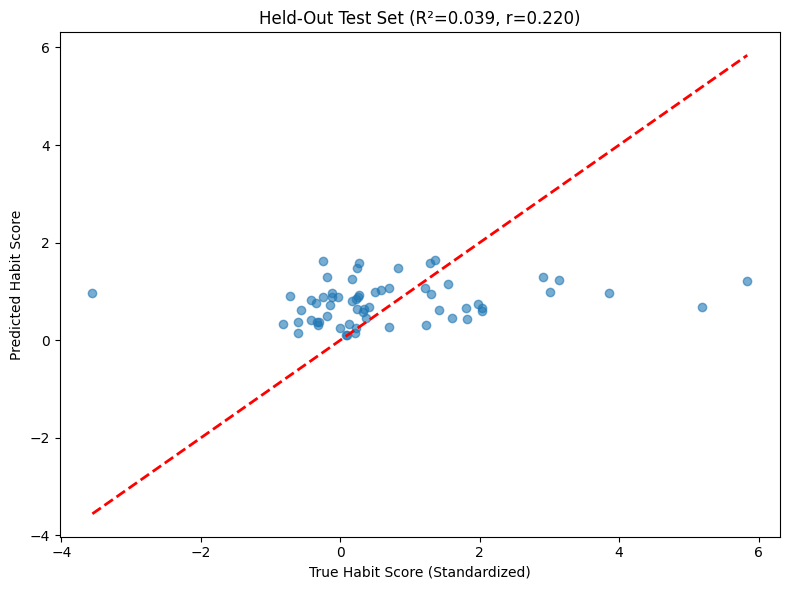

In [26]:
# Add this after your LOOCV results:

print(f"\n{'='*60}")
print("EVALUATING ON HELD-OUT TEST SET")
print(f"{'='*60}")

# Preprocess held-out set same way as training
scaler_final = StandardScaler().fit(X_cont_arr)
X_train_scaled = scaler_final.transform(X_cont_arr)
X_test_scaled = scaler_final.transform(X_cont_arr_test_holdout)

# Feature selection if needed
if best_deployment_config['n_features'] != 'all':
    selector_final = SelectKBest(f_classif, k=best_deployment_config['n_features'])
    X_train_selected = selector_final.fit_transform(X_train_scaled, y_arr)
    X_test_selected = selector_final.transform(X_test_scaled)
else:
    X_train_selected = X_train_scaled
    X_test_selected = X_test_scaled

# PCA if needed
if do_PCA:
    pca_final = PCA(n_components=pca_var).fit(X_train_selected)
    X_train_pca = pca_final.transform(X_train_selected)
    X_test_pca = pca_final.transform(X_test_selected)
else:
    X_train_pca = X_train_selected
    X_test_pca = X_test_selected

# Add group back
X_train_final = np.column_stack((group_arr, X_train_pca))
X_test_final = np.column_stack((group_arr_test_holdout, X_test_pca))

# Train final model on all training data
model_class = models_to_test[best_deployment_config['model_name']]['model']
if best_deployment_config['model_name'] in ['SVR_rbf', 'SVR']:
    final_model = model_class(**best_deployment_config['params'])
else:
    final_model = model_class(**best_deployment_config['params'], random_state=42)

final_model.fit(X_train_final, y_arr)

# Predict on held-out
y_pred_holdout = final_model.predict(X_test_final)

# Compute metrics
r2_holdout = r2_score(y_arr_test_holdout, y_pred_holdout)
rmse_holdout = np.sqrt(mean_squared_error(y_arr_test_holdout, y_pred_holdout))
mae_holdout = mean_absolute_error(y_arr_test_holdout, y_pred_holdout)
pearson_r_holdout, pearson_p_holdout = pearsonr(y_arr_test_holdout, y_pred_holdout)
spearman_r_holdout, spearman_p_holdout = spearmanr(y_arr_test_holdout, y_pred_holdout)

print(f"\nHeld-out test set results (n={len(y_arr_test_holdout)}):")
print(f"R²: {r2_holdout:.4f}")
print(f"RMSE: {rmse_holdout:.4f}")
print(f"MAE: {mae_holdout:.4f}")
print(f"Pearson r: {pearson_r_holdout:.4f} (p={pearson_p_holdout:.4f})")
print(f"Spearman r: {spearman_r_holdout:.4f} (p={spearman_p_holdout:.4f})")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_arr_test_holdout, y_pred_holdout, alpha=0.6)
plt.plot([y_arr_test_holdout.min(), y_arr_test_holdout.max()],
         [y_arr_test_holdout.min(), y_arr_test_holdout.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'Held-Out Test Set (R²={r2_holdout:.3f}, r={pearson_r_holdout:.3f})')
plt.tight_layout()
plt.show()


Total n=306, mean=0.745, std=1.481, group_vals=[-1  1]

DATA SPLIT:
Training set (for LOOCV): n=244, mean=0.764, std=1.488
Held-out test set: n=62, mean=0.670, std=1.440

Stratification: Site + Group + Outcome

Training set:
  Groups: (array([-1,  1]), array([119, 125]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

Held-out test set:
  Groups: (array([-1,  1]), array([30, 32]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

RUNNING NESTED LOOCV ON TRAINING SET

n=244, mean=0.764, std=1.488, group_vals=[-1  1]
Total n=244, positive=186 (0.764), group_vals=[-1  1]


Outer CV folds: 100%|██████████| 244/244 [00:17<00:00, 14.07it/s]



NESTED LOOCV REGRESSION RESULTS:
R²: 0.0443
RMSE: 1.4549
MAE: 1.0951
Pearson r: 0.2281 (p=0.0003)
Spearman r: 0.1616 (p=0.0115)


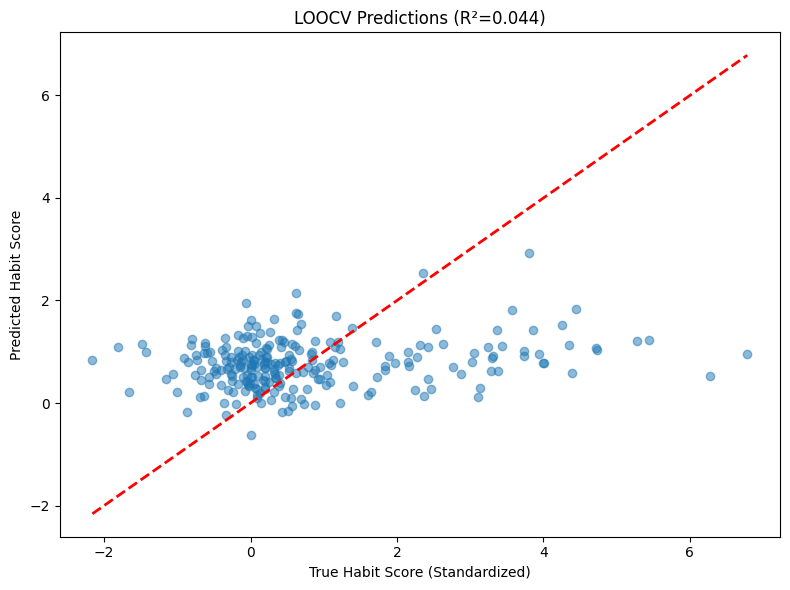


CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  Ridge: 139/244 folds (57.0%)
  ElasticNet: 64/244 folds (26.2%)
  Lasso: 41/244 folds (16.8%)

Number of features selected:
  all features: 244/244 folds (100.0%)

Most common configurations:
  Ridge_nfeatall_alpha10.0: 139/244 folds (57.0%)
  ElasticNet_nfeatall_alpha0.1_l1_ratio0.5: 64/244 folds (26.2%)
  Lasso_nfeatall_alpha0.1: 41/244 folds (16.8%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: Ridge
Number of features: all
Hyperparameters: {'alpha': 10.0}


In [19]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression  # CHANGE THIS


features_data = run1_features_df.copy().reset_index(drop=True)
# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
y = block_df["behav_adaptation_SCORE"]
subjects = block_df["subID"].reset_index(drop=True)
sites = block_df["site"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)

drop_cols = {"subID", "group", "site", "behav_adaptation_SCORE", "isHabitual"}
X_cont = block_df.drop(columns=list(drop_cols))

# Convert to arrays FIRST (before splitting)
X_cont_arr_full = X_cont.values
y_arr_full = np.asarray(y).astype(float)  # Keep as float for regression
group_arr_full = group.values
subjects_arr_full = subjects.values
sites_arr_full = sites.values

print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}, group_vals={np.unique(group_arr_full)}")

# ============================================
# CREATE HELD-OUT TEST SET (20%)
# ============================================
# Stratify by site + group + outcome
y_binned = pd.qcut(y, q=3, labels=['T1', 'T2', 'T3'], duplicates='drop')
strat_labels = (sites.astype(str) + '_' + 
                group.astype(str) + '_' + 
                y_binned.astype(str))

train_idx, test_idx = train_test_split(
    np.arange(len(y_arr_full)),
    test_size=0.20,
    stratify=strat_labels,
    random_state=42
)

# ============================================
# TRAINING SET (for LOOCV nested CV)
# ============================================
X_cont_arr = X_cont_arr_full[train_idx]
# get the relevant df X_cont :
X_cont_main_tr_set = pd.DataFrame(X_cont_arr, columns=X_cont.columns)
y_arr = y_arr_full[train_idx]
subjects = pd.Series(subjects_arr_full[train_idx]).reset_index(drop=True)  # Convert back to Series for compatibility
group = pd.Series(group_arr_full[train_idx]).reset_index(drop=True)  # Convert back to Series for compatibility
group_arr = group.values

# ============================================
# HELD-OUT TEST SET (saved for final evaluation)
# ============================================
X_cont_arr_test_holdout = X_cont_arr_full[test_idx]
y_arr_test_holdout = y_arr_full[test_idx]
subjects_test_holdout = subjects_arr_full[test_idx]
group_arr_test_holdout = group_arr_full[test_idx]
sites_test_holdout = sites_arr_full[test_idx]

print(f"\n{'='*60}")
print(f"DATA SPLIT:")
print(f"{'='*60}")
print(f"Training set (for LOOCV): n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")
print(f"Held-out test set: n={len(y_arr_test_holdout)}, mean={y_arr_test_holdout.mean():.3f}, std={y_arr_test_holdout.std():.3f}")
print(f"\nStratification: Site + Group + Outcome")

# Check distributions
print(f"\nTraining set:")
print(f"  Groups: {np.unique(group_arr, return_counts=True)}")
print(f"  Sites: {np.unique(sites_arr_full[train_idx], return_counts=True)[0]}")

print(f"\nHeld-out test set:")
print(f"  Groups: {np.unique(group_arr_test_holdout, return_counts=True)}")
print(f"  Sites: {np.unique(sites_test_holdout, return_counts=True)[0]}")

# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")

print(f"n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}, group_vals={np.unique(group_arr)}")



# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    # 'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

models_to_test = {
    # 'LinearRegression': {'model': LinearRegression, 'params': {}},  # No regularization
    'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},  # Only true elastic net
    'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params':  {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"
measure_to_pick_model = "mse"  # or "mse"
measure_to_pick_model = "r2"  # or "mse"
# measure_to_pick_model = 'mae'  # or "mse"


# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
# n_features_to_test = [3,5,10,'all']
n_features_to_test = ['all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")

# X_cont_arr
# y_arr
# subjects
# group
# group_arr


# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx, train_index, test_index, X_cont_arr, y_arr, group_arr, 
                        subjects, group_series, models_to_test, n_features_to_test, 
                        n_inner_folds, measure_to_pick_model):
    
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]
    group_train_Outer = group_arr[train_index]
    group_test_Outer = group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV - CHANGED to KFold for regression
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
    
    best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf  # CHANGED
    best_config = None
    
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_r2 = []
                inner_mse = []
                inner_mae = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):  # CHANGED: removed y stratification
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]
                    group_train_Inner = group_train_Outer[inner_train_idx]
                    group_test_Inner = group_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # # Feature selection
                    # n_features = X_cont_train_Inner_scaled.shape[1]
                    # if n_feat != "all" and n_feat < n_features:
                    #     selector = SelectKBest(f_regression, k=n_feat)
                    #     X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                    #     X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # # PCA
                    # if do_PCA:
                    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                    #     X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    #     X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    # else:
                    #     X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                    #     X_cont_test_Inner_pca = X_cont_test_Inner_scaled


                    # PCA on Inner TRAIN only (BEFORE SelectKBest)
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Feature selection (AFTER PCA)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)


                    # Add group
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression']:  # Add any other models without random_state
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate - CHANGED metrics
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_r2.append(r2_score(y_test_Inner, y_test_Inner_pred))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_test_Inner_pred))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_test_Inner_pred))
                
                # Average performance
                mean_inner_r2 = np.mean(inner_r2)
                mean_inner_mse = np.mean(inner_mse)
                mean_inner_mae = np.mean(inner_mae)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae
                }
                
                # Select best config - CHANGED
                if measure_to_pick_model == "r2" and mean_inner_r2 > best_inner_score:
                    best_inner_score = mean_inner_r2
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mse" and mean_inner_mse < best_inner_score:
                    best_inner_score = mean_inner_mse
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mae" and mean_inner_mae < best_inner_score:
                    best_inner_score = mean_inner_mae
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
    
    # Retrain on outer fold (same as before, but remove predict_proba calls)
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    
    # n_features_outer = X_cont_train_Outer_scaled.shape[1]
    # k_final = best_config["n_features"]
    # if k_final == "all" or k_final >= n_features_outer:
    #     X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    # else:
    #     selector_final = SelectKBest(f_regression, k=best_config['n_features'])
    #     X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
    #     X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    
    # if do_PCA:
    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
    #     X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    #     X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # else:
    #     X_cont_train_Outer_pca = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_pca = X_cont_test_Outer_scaled
        
    # PCA on Outer TRAIN only (BEFORE SelectKBest)
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled
    
    # Feature selection (AFTER PCA)
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_regression, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Counterfactuals
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, 
                                                np.where(group_counterfactual_test_Outer == 1, -1, 
                                                        group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
    
    # Train final model
    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    # Predict - REMOVED predict_proba
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    
    # Counterfactual predictions - REMOVED predict_proba
    y_pred_cf = model_final.predict(X_counterfactual_test_Outer)[0]
    y_pred_cf_x2 = model_final.predict(X_counterfactual_cf_x2_test_Outer)[0]

    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_counterfactual": y_pred_cf,
        "y_pred_counterfactual_x2": y_pred_cf_x2,
        "matching_sub": matching_sub,
        "matching_group": matching_group,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }
# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)
y_pred_counterfactual_all = np.array([r["y_pred_counterfactual"] for r in results], dtype=float)
y_pred_counterfactual_x2_all = np.array([r["y_pred_counterfactual_x2"] for r in results], dtype=float)

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')




EVALUATING ON HELD-OUT TEST SET

Held-out test set results (n=62):
R²: -0.0193
RMSE: 1.4539
MAE: 1.0144
Pearson r: 0.1724 (p=0.1802)
Spearman r: 0.1254 (p=0.3315)


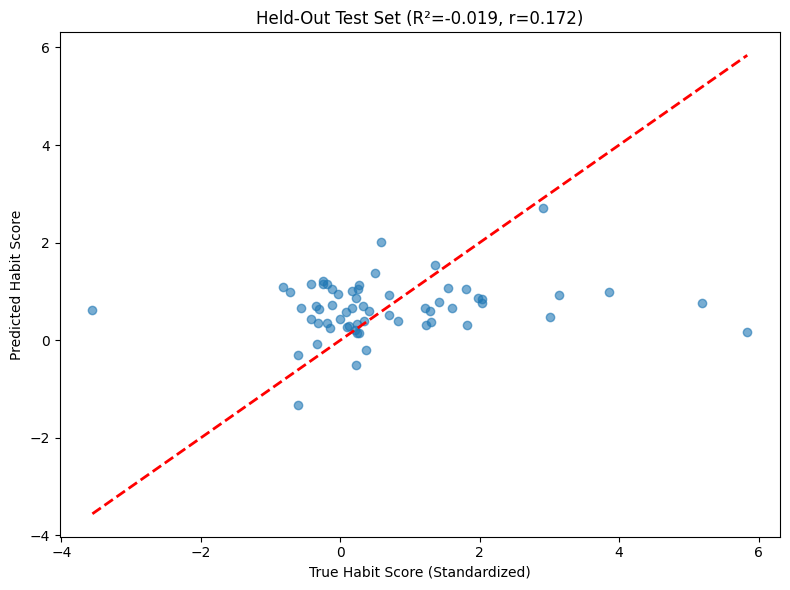

In [20]:
# Add this after your LOOCV results:

print(f"\n{'='*60}")
print("EVALUATING ON HELD-OUT TEST SET")
print(f"{'='*60}")

# Preprocess held-out set same way as training
scaler_final = StandardScaler().fit(X_cont_arr)
X_train_scaled = scaler_final.transform(X_cont_arr)
X_test_scaled = scaler_final.transform(X_cont_arr_test_holdout)

# Feature selection if needed
if best_deployment_config['n_features'] != 'all':
    selector_final = SelectKBest(f_classif, k=best_deployment_config['n_features'])
    X_train_selected = selector_final.fit_transform(X_train_scaled, y_arr)
    X_test_selected = selector_final.transform(X_test_scaled)
else:
    X_train_selected = X_train_scaled
    X_test_selected = X_test_scaled

# PCA if needed
if do_PCA:
    pca_final = PCA(n_components=pca_var).fit(X_train_selected)
    X_train_pca = pca_final.transform(X_train_selected)
    X_test_pca = pca_final.transform(X_test_selected)
else:
    X_train_pca = X_train_selected
    X_test_pca = X_test_selected

# Add group back
X_train_final = np.column_stack((group_arr, X_train_pca))
X_test_final = np.column_stack((group_arr_test_holdout, X_test_pca))

# Train final model on all training data
model_class = models_to_test[best_deployment_config['model_name']]['model']
if best_deployment_config['model_name'] in ['SVR_rbf', 'SVR']:
    final_model = model_class(**best_deployment_config['params'])
else:
    final_model = model_class(**best_deployment_config['params'], random_state=42)

final_model.fit(X_train_final, y_arr)

# Predict on held-out
y_pred_holdout = final_model.predict(X_test_final)

# Compute metrics
r2_holdout = r2_score(y_arr_test_holdout, y_pred_holdout)
rmse_holdout = np.sqrt(mean_squared_error(y_arr_test_holdout, y_pred_holdout))
mae_holdout = mean_absolute_error(y_arr_test_holdout, y_pred_holdout)
pearson_r_holdout, pearson_p_holdout = pearsonr(y_arr_test_holdout, y_pred_holdout)
spearman_r_holdout, spearman_p_holdout = spearmanr(y_arr_test_holdout, y_pred_holdout)

print(f"\nHeld-out test set results (n={len(y_arr_test_holdout)}):")
print(f"R²: {r2_holdout:.4f}")
print(f"RMSE: {rmse_holdout:.4f}")
print(f"MAE: {mae_holdout:.4f}")
print(f"Pearson r: {pearson_r_holdout:.4f} (p={pearson_p_holdout:.4f})")
print(f"Spearman r: {spearman_r_holdout:.4f} (p={spearman_p_holdout:.4f})")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_arr_test_holdout, y_pred_holdout, alpha=0.6)
plt.plot([y_arr_test_holdout.min(), y_arr_test_holdout.max()],
         [y_arr_test_holdout.min(), y_arr_test_holdout.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'Held-Out Test Set (R²={r2_holdout:.3f}, r={pearson_r_holdout:.3f})')
plt.tight_layout()
plt.show()


On all - only LOOCV

Total n=306, mean=0.745, std=1.481, group_vals=[-1  1]

DATA SPLIT:
Training set (for LOOCV): n=306, mean=0.745, std=1.479
Held-out test set: n=62, mean=0.670, std=1.440

Stratification: Site + Group + Outcome

Training set:
  Groups: (array([-1,  1]), array([149, 157]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

Held-out test set:
  Groups: (array([-1,  1]), array([30, 32]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

RUNNING NESTED LOOCV ON TRAINING SET

n=306, mean=0.745, std=1.479, group_vals=[-1  1]
Total n=306, positive=227 (0.745), group_vals=[-1  1]


Outer CV folds: 100%|██████████| 306/306 [00:09<00:00, 33.22it/s]



NESTED LOOCV REGRESSION RESULTS:
R²: 0.0478
RMSE: 1.4432
MAE: 1.0651
Pearson r: 0.2200 (p=0.0001)
Spearman r: 0.1738 (p=0.0023)


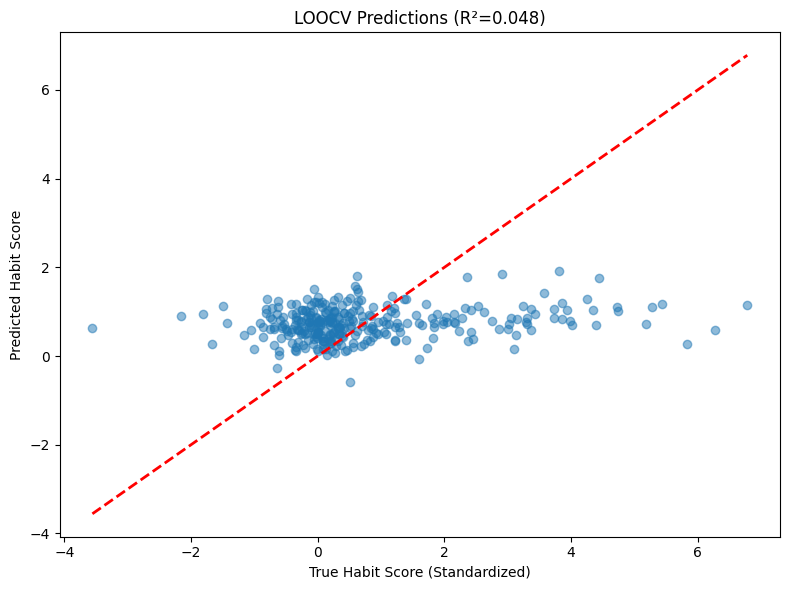


CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  ElasticNet: 306/306 folds (100.0%)

Number of features selected:
  10 features: 261/306 folds (85.3%)
  5 features: 43/306 folds (14.1%)
  3 features: 2/306 folds (0.7%)

Most common configurations:
  ElasticNet_nfeat10_alpha0.1_l1_ratio0.5: 261/306 folds (85.3%)
  ElasticNet_nfeat5_alpha0.1_l1_ratio0.5: 43/306 folds (14.1%)
  ElasticNet_nfeat3_alpha0.1_l1_ratio0.5: 2/306 folds (0.7%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: ElasticNet
Number of features: 10
Hyperparameters: {'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 5000}


In [22]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression  # CHANGE THIS


features_data = run1_features_df.copy().reset_index(drop=True)
# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
y = block_df["behav_adaptation_SCORE"]
subjects = block_df["subID"].reset_index(drop=True)
sites = block_df["site"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)

drop_cols = {"subID", "group", "site", "behav_adaptation_SCORE", "isHabitual"}
X_cont = block_df.drop(columns=list(drop_cols))

# Convert to arrays FIRST (before splitting)
X_cont_arr_full = X_cont.values
y_arr_full = np.asarray(y).astype(float)  # Keep as float for regression
group_arr_full = group.values
subjects_arr_full = subjects.values
sites_arr_full = sites.values

print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}, group_vals={np.unique(group_arr_full)}")

# ============================================
# CREATE HELD-OUT TEST SET (20%)
# ============================================
# Stratify by site + group + outcome
y_binned = pd.qcut(y, q=3, labels=['T1', 'T2', 'T3'], duplicates='drop')
strat_labels = (sites.astype(str) + '_' + 
                group.astype(str) + '_' + 
                y_binned.astype(str))

train_idx, test_idx = train_test_split(
    np.arange(len(y_arr_full)),
    test_size=0.20,
    stratify=strat_labels,
    random_state=42
)

# ============================================
# TRAINING SET (for LOOCV nested CV)
# ============================================
X_cont_arr = X_cont_arr_full
# get the relevant df X_cont :
X_cont_main_tr_set = pd.DataFrame(X_cont_arr, columns=X_cont.columns)
y_arr = y_arr_full
subjects = pd.Series(subjects_arr_full).reset_index(drop=True)  # Convert back to Series for compatibility
group = pd.Series(group_arr_full).reset_index(drop=True)  # Convert back to Series for compatibility
group_arr = group.values


print(f"\n{'='*60}")
print(f"DATA SPLIT:")
print(f"{'='*60}")
print(f"Training set (for LOOCV): n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")
print(f"Held-out test set: n={len(y_arr_test_holdout)}, mean={y_arr_test_holdout.mean():.3f}, std={y_arr_test_holdout.std():.3f}")
print(f"\nStratification: Site + Group + Outcome")

# Check distributions
print(f"\nTraining set:")
print(f"  Groups: {np.unique(group_arr, return_counts=True)}")
print(f"  Sites: {np.unique(sites_arr_full[train_idx], return_counts=True)[0]}")

print(f"\nHeld-out test set:")
print(f"  Groups: {np.unique(group_arr_test_holdout, return_counts=True)}")
print(f"  Sites: {np.unique(sites_test_holdout, return_counts=True)[0]}")

# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")

print(f"n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}, group_vals={np.unique(group_arr)}")



# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    # 'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

models_to_test = {
    # 'LinearRegression': {'model': LinearRegression, 'params': {}},  # No regularization
    # 'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    # 'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},  # Only true elastic net
    # 'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params':  {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"
measure_to_pick_model = "mse"  # or "mse"
measure_to_pick_model = "r2"  # or "mse"


# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
# n_features_to_test = ['all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")

# X_cont_arr
# y_arr
# subjects
# group
# group_arr


# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx, train_index, test_index, X_cont_arr, y_arr, group_arr, 
                        subjects, group_series, models_to_test, n_features_to_test, 
                        n_inner_folds, measure_to_pick_model):
    
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]
    group_train_Outer = group_arr[train_index]
    group_test_Outer = group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV - CHANGED to KFold for regression
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
    
    best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf  # CHANGED
    best_config = None
    
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_r2 = []
                inner_mse = []
                inner_mae = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):  # CHANGED: removed y stratification
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]
                    group_train_Inner = group_train_Outer[inner_train_idx]
                    group_test_Inner = group_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # # Feature selection
                    # n_features = X_cont_train_Inner_scaled.shape[1]
                    # if n_feat != "all" and n_feat < n_features:
                    #     selector = SelectKBest(f_regression, k=n_feat)
                    #     X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                    #     X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # # PCA
                    # if do_PCA:
                    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                    #     X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    #     X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    # else:
                    #     X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                    #     X_cont_test_Inner_pca = X_cont_test_Inner_scaled


                    # PCA on Inner TRAIN only (BEFORE SelectKBest)
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Feature selection (AFTER PCA)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)


                    # Add group
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression']:  # Add any other models without random_state
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate - CHANGED metrics
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_r2.append(r2_score(y_test_Inner, y_test_Inner_pred))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_test_Inner_pred))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_test_Inner_pred))
                
                # Average performance
                mean_inner_r2 = np.mean(inner_r2)
                mean_inner_mse = np.mean(inner_mse)
                mean_inner_mae = np.mean(inner_mae)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae
                }
                
                # Select best config - CHANGED
                if measure_to_pick_model == "r2" and mean_inner_r2 > best_inner_score:
                    best_inner_score = mean_inner_r2
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mse" and mean_inner_mse < best_inner_score:
                    best_inner_score = mean_inner_mse
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
    
    # Retrain on outer fold (same as before, but remove predict_proba calls)
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    
    # n_features_outer = X_cont_train_Outer_scaled.shape[1]
    # k_final = best_config["n_features"]
    # if k_final == "all" or k_final >= n_features_outer:
    #     X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    # else:
    #     selector_final = SelectKBest(f_regression, k=best_config['n_features'])
    #     X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
    #     X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    
    # if do_PCA:
    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
    #     X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    #     X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # else:
    #     X_cont_train_Outer_pca = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_pca = X_cont_test_Outer_scaled
        
    # PCA on Outer TRAIN only (BEFORE SelectKBest)
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled
    
    # Feature selection (AFTER PCA)
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_regression, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Counterfactuals
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, 
                                                np.where(group_counterfactual_test_Outer == 1, -1, 
                                                        group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
    
    # Train final model
    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    # Predict - REMOVED predict_proba
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    
    # Counterfactual predictions - REMOVED predict_proba
    y_pred_cf = model_final.predict(X_counterfactual_test_Outer)[0]
    y_pred_cf_x2 = model_final.predict(X_counterfactual_cf_x2_test_Outer)[0]

    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_counterfactual": y_pred_cf,
        "y_pred_counterfactual_x2": y_pred_cf_x2,
        "matching_sub": matching_sub,
        "matching_group": matching_group,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }
# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)
y_pred_counterfactual_all = np.array([r["y_pred_counterfactual"] for r in results], dtype=float)
y_pred_counterfactual_x2_all = np.array([r["y_pred_counterfactual_x2"] for r in results], dtype=float)

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')

# # ============================================
# # TRAIN FINAL MODEL ON ALL DATA
# # ============================================

# print(f'\n{"="*60}')
# print(f'Training final model on all data...')
# print(f'{"="*60}')

# # Get model class
# model_class = models_to_test[best_deployment_config['model_name']]['model']

# # Feature selection on all data
# if best_deployment_config['n_features'] < n_features:
#     selector_all = SelectKBest(f_classif, k=best_deployment_config['n_features'])
#     X_all_sel = selector_all.fit_transform(X, y)
#     selected_feature_indices = selector_all.get_support(indices=True)
#     selected_features = X.columns[selected_feature_indices]
#     print(f'Selected features: {list(selected_features)}')
# else:
#     X_all_sel = X.values
#     selected_features = X.columns
#     print(f'Using all features')

# # Train final model
# model_all = model_class(**best_deployment_config['params'], random_state=42)
# model_all.fit(X_all_sel, y)

# # Feature importance
# print(f'\nComputing feature importance...')
# feature_importance = permutation_importance(model_all, X_all_sel, y, n_repeats=100, random_state=42)

# # # ============================================
# # # RETURN RESULTS
# # # ============================================

# # results = {
# #     # Performance metrics
# #     'accuracy': accuracy,
# #     'auc_score': auc_score,
# #     'conf_matrix': conf_matrix,
# #     'fpr': fpr,
# #     'tpr': tpr,
# #     'thresholds': thresholds,
    
# #     # Predictions
# #     'y_true': y_true_all,
# #     'y_pred': y_pred_all,
# #     'y_pred_proba': y_pred_proba_all,
# #     'y_pred_proba_counterfactual': np.array(y_pred_proba_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual': np.array(y_pred_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_proba_counterfactual_x2': np.array(y_pred_proba_counterfactual_x2_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual_x2': np.array(y_pred_counterfactual_x2_all) if X_counterfactual is not None else None,
    
# #     # Metadata
# #     'matching_group': matching_group_all,
# #     'matching_sub': matching_sub_all,
    
# #     # Configuration info
# #     'selected_configs': selected_configs,
# #     'model_counts': model_counts,
# #     'nfeat_counts': nfeat_counts,
# #     'best_deployment_config': best_deployment_config,
    
# #     # Final model trained on all data
# #     'model_all': model_all,
# #     'feature_importance': feature_importance,
# #     'selected_features': selected_features,
# # }




# - Now with AUC
# aaaaaaaaaaaaaa


In [ ]:
NOTE - RF was never chosen (using the limited amount of hyperparameter)

without RF:
Total n=306, mean=0.745, std=1.481, group_vals=[-1  1]

============================================================
DATA SPLIT:
============================================================
Training set (for LOOCV): n=306, mean=0.745, std=1.479
Held-out test set: n=62, mean=0.670, std=1.440

Stratification: Site + Group + Outcome

Training set:
  Groups: (array([-1,  1]), array([149, 157]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

Held-out test set:
  Groups: (array([-1,  1]), array([30, 32]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

============================================================
RUNNING NESTED LOOCV ON TRAINING SET
============================================================

n=306, mean=0.745, std=1.479, group_vals=[-1  1]
Total n=306, positive=227 (0.745), group_vals=[-1  1]
Outer CV folds: 100%|██████████| 306/306 [01:25<00:00,  3.57it/s]

============================================================
NESTED LOOCV REGRESSION RESULTS:
============================================================
R²: 0.0468
RMSE: 1.4440
MAE: 1.0654
Pearson r: 0.2181 (p=0.0001)
Spearman r: 0.1730 (p=0.0024)


SyntaxError: invalid character '█' (U+2588) (286711546.py, line 26)

on all - new


Total n=306, mean=0.745, std=1.481, group_vals=[-1  1]

DATA SPLIT:
Training set (for LOOCV): n=306, mean=0.745, std=1.479
Held-out test set: n=62, mean=0.670, std=1.440

Stratification: Site + Group + Outcome

Training set:
  Groups: (array([-1,  1]), array([149, 157]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

Held-out test set:
  Groups: (array([-1,  1]), array([30, 32]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

RUNNING NESTED LOOCV ON TRAINING SET

n=306, mean=0.745, std=1.479, group_vals=[-1  1]
Total n=306, positive=227 (0.745), group_vals=[-1  1]


Outer CV folds: 100%|██████████| 306/306 [00:25<00:00, 11.97it/s]



NESTED LOOCV REGRESSION RESULTS:
R²: 0.0492
RMSE: 1.4422
MAE: 1.0650
Pearson r: 0.2229 (p=0.0001)
Spearman r: 0.1735 (p=0.0023)


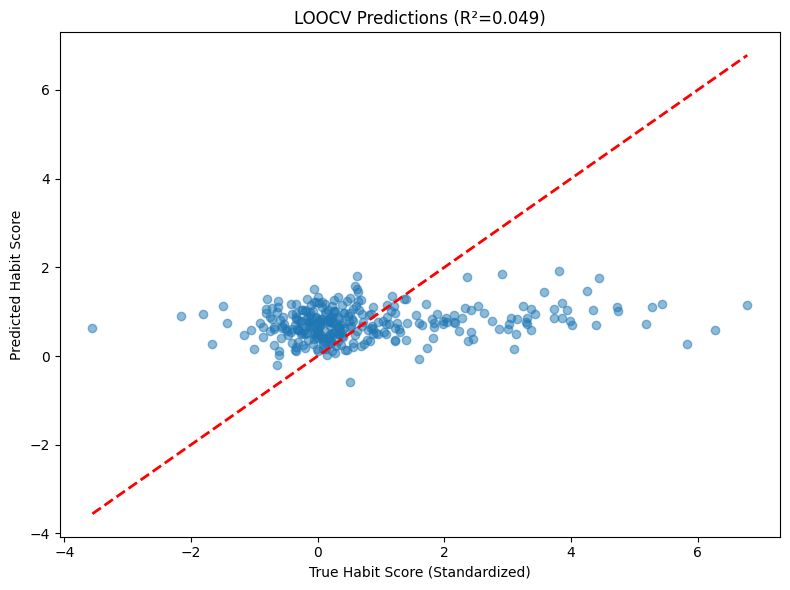


CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  ElasticNet: 306/306 folds (100.0%)

Number of features selected:
  all features: 306/306 folds (100.0%)

Most common configurations:
  ElasticNet_nfeatall_alpha0.1_l1_ratio0.5: 306/306 folds (100.0%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: ElasticNet
Number of features: all
Hyperparameters: {'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 5000}


In [22]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression  # CHANGE THIS


features_data = run1_features_df.copy().reset_index(drop=True)
# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
y = block_df["behav_adaptation_SCORE"]
subjects = block_df["subID"].reset_index(drop=True)
sites = block_df["site"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)

drop_cols = {"subID", "group", "site", "behav_adaptation_SCORE", "isHabitual"}
X_cont = block_df.drop(columns=list(drop_cols))

# Convert to arrays FIRST (before splitting)
X_cont_arr_full = X_cont.values
y_arr_full = np.asarray(y).astype(float)  # Keep as float for regression
group_arr_full = group.values
subjects_arr_full = subjects.values
sites_arr_full = sites.values

print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}, group_vals={np.unique(group_arr_full)}")

# ============================================
# CREATE HELD-OUT TEST SET (20%)
# ============================================
# Stratify by site + group + outcome
y_binned = pd.qcut(y, q=3, labels=['T1', 'T2', 'T3'], duplicates='drop')
strat_labels = (sites.astype(str) + '_' + 
                group.astype(str) + '_' + 
                y_binned.astype(str))

train_idx, test_idx = train_test_split(
    np.arange(len(y_arr_full)),
    test_size=0.20,
    stratify=strat_labels,
    random_state=42
)

# ============================================
# TRAINING SET (for LOOCV nested CV)
# ============================================
X_cont_arr = X_cont_arr_full
# get the relevant df X_cont :
X_cont_main_tr_set = pd.DataFrame(X_cont_arr, columns=X_cont.columns)
y_arr = y_arr_full
subjects = pd.Series(subjects_arr_full).reset_index(drop=True)  # Convert back to Series for compatibility
group = pd.Series(group_arr_full).reset_index(drop=True)  # Convert back to Series for compatibility
group_arr = group.values


print(f"\n{'='*60}")
print(f"DATA SPLIT:")
print(f"{'='*60}")
print(f"Training set (for LOOCV): n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")
print(f"Held-out test set: n={len(y_arr_test_holdout)}, mean={y_arr_test_holdout.mean():.3f}, std={y_arr_test_holdout.std():.3f}")
print(f"\nStratification: Site + Group + Outcome")

# Check distributions
print(f"\nTraining set:")
print(f"  Groups: {np.unique(group_arr, return_counts=True)}")
print(f"  Sites: {np.unique(sites_arr_full[train_idx], return_counts=True)[0]}")

print(f"\nHeld-out test set:")
print(f"  Groups: {np.unique(group_arr_test_holdout, return_counts=True)}")
print(f"  Sites: {np.unique(sites_test_holdout, return_counts=True)[0]}")

# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")

print(f"n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}, group_vals={np.unique(group_arr)}")



# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    # 'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

models_to_test = {
    # 'LinearRegression': {'model': LinearRegression, 'params': {}},  # No regularization
    'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},  # Only true elastic net
    'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params':  {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"
measure_to_pick_model = "mse"  # or "mse"
measure_to_pick_model = "r2"  # or "mse"


# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
n_features_to_test = ['all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")

# X_cont_arr
# y_arr
# subjects
# group
# group_arr


# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx, train_index, test_index, X_cont_arr, y_arr, group_arr, 
                        subjects, group_series, models_to_test, n_features_to_test, 
                        n_inner_folds, measure_to_pick_model):
    
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]
    group_train_Outer = group_arr[train_index]
    group_test_Outer = group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV - CHANGED to KFold for regression
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
    
    best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf  # CHANGED
    best_config = None
    
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_r2 = []
                inner_mse = []
                inner_mae = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):  # CHANGED: removed y stratification
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]
                    group_train_Inner = group_train_Outer[inner_train_idx]
                    group_test_Inner = group_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # # Feature selection
                    # n_features = X_cont_train_Inner_scaled.shape[1]
                    # if n_feat != "all" and n_feat < n_features:
                    #     selector = SelectKBest(f_regression, k=n_feat)
                    #     X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                    #     X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # # PCA
                    # if do_PCA:
                    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                    #     X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    #     X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    # else:
                    #     X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                    #     X_cont_test_Inner_pca = X_cont_test_Inner_scaled


                    # PCA on Inner TRAIN only (BEFORE SelectKBest)
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Feature selection (AFTER PCA)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)


                    # Add group
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression']:  # Add any other models without random_state
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate - CHANGED metrics
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_r2.append(r2_score(y_test_Inner, y_test_Inner_pred))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_test_Inner_pred))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_test_Inner_pred))
                
                # Average performance
                mean_inner_r2 = np.mean(inner_r2)
                mean_inner_mse = np.mean(inner_mse)
                mean_inner_mae = np.mean(inner_mae)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae
                }
                
                # Select best config - CHANGED
                if measure_to_pick_model == "r2" and mean_inner_r2 > best_inner_score:
                    best_inner_score = mean_inner_r2
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mse" and mean_inner_mse < best_inner_score:
                    best_inner_score = mean_inner_mse
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
    
    # Retrain on outer fold (same as before, but remove predict_proba calls)
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    
    # n_features_outer = X_cont_train_Outer_scaled.shape[1]
    # k_final = best_config["n_features"]
    # if k_final == "all" or k_final >= n_features_outer:
    #     X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    # else:
    #     selector_final = SelectKBest(f_regression, k=best_config['n_features'])
    #     X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
    #     X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    
    # if do_PCA:
    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
    #     X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    #     X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # else:
    #     X_cont_train_Outer_pca = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_pca = X_cont_test_Outer_scaled
        
    # PCA on Outer TRAIN only (BEFORE SelectKBest)
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled
    
    # Feature selection (AFTER PCA)
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_regression, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Counterfactuals
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, 
                                                np.where(group_counterfactual_test_Outer == 1, -1, 
                                                        group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
    
    # Train final model
    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    # Predict - REMOVED predict_proba
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    
    # Counterfactual predictions - REMOVED predict_proba
    y_pred_cf = model_final.predict(X_counterfactual_test_Outer)[0]
    y_pred_cf_x2 = model_final.predict(X_counterfactual_cf_x2_test_Outer)[0]

    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_counterfactual": y_pred_cf,
        "y_pred_counterfactual_x2": y_pred_cf_x2,
        "matching_sub": matching_sub,
        "matching_group": matching_group,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }
# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)
y_pred_counterfactual_all = np.array([r["y_pred_counterfactual"] for r in results], dtype=float)
y_pred_counterfactual_x2_all = np.array([r["y_pred_counterfactual_x2"] for r in results], dtype=float)

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')

# # ============================================
# # TRAIN FINAL MODEL ON ALL DATA
# # ============================================

# print(f'\n{"="*60}')
# print(f'Training final model on all data...')
# print(f'{"="*60}')

# # Get model class
# model_class = models_to_test[best_deployment_config['model_name']]['model']

# # Feature selection on all data
# if best_deployment_config['n_features'] < n_features:
#     selector_all = SelectKBest(f_classif, k=best_deployment_config['n_features'])
#     X_all_sel = selector_all.fit_transform(X, y)
#     selected_feature_indices = selector_all.get_support(indices=True)
#     selected_features = X.columns[selected_feature_indices]
#     print(f'Selected features: {list(selected_features)}')
# else:
#     X_all_sel = X.values
#     selected_features = X.columns
#     print(f'Using all features')

# # Train final model
# model_all = model_class(**best_deployment_config['params'], random_state=42)
# model_all.fit(X_all_sel, y)

# # Feature importance
# print(f'\nComputing feature importance...')
# feature_importance = permutation_importance(model_all, X_all_sel, y, n_repeats=100, random_state=42)

# # # ============================================
# # # RETURN RESULTS
# # # ============================================

# # results = {
# #     # Performance metrics
# #     'accuracy': accuracy,
# #     'auc_score': auc_score,
# #     'conf_matrix': conf_matrix,
# #     'fpr': fpr,
# #     'tpr': tpr,
# #     'thresholds': thresholds,
    
# #     # Predictions
# #     'y_true': y_true_all,
# #     'y_pred': y_pred_all,
# #     'y_pred_proba': y_pred_proba_all,
# #     'y_pred_proba_counterfactual': np.array(y_pred_proba_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual': np.array(y_pred_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_proba_counterfactual_x2': np.array(y_pred_proba_counterfactual_x2_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual_x2': np.array(y_pred_counterfactual_x2_all) if X_counterfactual is not None else None,
    
# #     # Metadata
# #     'matching_group': matching_group_all,
# #     'matching_sub': matching_sub_all,
    
# #     # Configuration info
# #     'selected_configs': selected_configs,
# #     'model_counts': model_counts,
# #     'nfeat_counts': nfeat_counts,
# #     'best_deployment_config': best_deployment_config,
    
# #     # Final model trained on all data
# #     'model_all': model_all,
# #     'feature_importance': feature_importance,
# #     'selected_features': selected_features,
# # }




# - Now with AUC
# aaaaaaaaaaaaaa


In [23]:
# ============================================
# PERMUTATION TEST — FULL NESTED CV
# with running p-value after each iteration
# ============================================

n_permutations = 1000  # start with 100, scale up if needed

# Observed values from your nested CV
obs_pearson = pearson_r
obs_spearman = spearman_r

null_pearson = []
null_spearman = []

print(f'Running {n_permutations} permutations of FULL nested LOOCV...')
print(f'Observed Pearson r = {obs_pearson:.4f}, Spearman ρ = {obs_spearman:.4f}')
print(f'{"="*70}')

for perm_i in range(n_permutations):
    # Shuffle y labels
    rng = np.random.RandomState(perm_i)
    y_perm = rng.permutation(y_arr)
    
    # Run full nested LOOCV with permuted y — parallelized over folds
    loo_perm = LeaveOneOut()
    outer_splits_perm = list(loo_perm.split(X_cont_arr))
    
    perm_results_i = Parallel(n_jobs=-1, prefer="processes")(
        delayed(_process_outer_fold)(
            fold_idx, train_index, test_index,
            X_cont_arr, y_perm, group_arr,  # <-- permuted y
            subjects, group,
            models_to_test, n_features_to_test,
            n_inner_folds, measure_to_pick_model
        )
        for fold_idx, (train_index, test_index) in enumerate(outer_splits_perm)
    )
    
    # Collect predictions
    perm_results_i = sorted(perm_results_i, key=lambda d: d["fold_idx"])
    y_true_perm = np.array([r["y_true"] for r in perm_results_i], dtype=float)
    y_pred_perm = np.array([r["y_pred"] for r in perm_results_i], dtype=float)
    
    r_perm, _ = pearsonr(y_true_perm, y_pred_perm)
    rho_perm, _ = spearmanr(y_true_perm, y_pred_perm)
    
    null_pearson.append(r_perm)
    null_spearman.append(rho_perm)
    
    # Running p-value
    n_so_far = len(null_pearson)
    running_p_pearson = (np.sum(np.array(null_pearson) >= obs_pearson) + 1) / (n_so_far + 1)
    running_p_spearman = (np.sum(np.array(null_spearman) >= obs_spearman) + 1) / (n_so_far + 1)
    
    print(f'Perm {perm_i+1:4d}/{n_permutations} | '
          f'null_r={r_perm:+.4f} | '
          f'running p(Pearson)={running_p_pearson:.4f} | '
          f'running p(Spearman)={running_p_spearman:.4f}')

# ============================================
# FINAL RESULTS
# ============================================
null_pearson = np.array(null_pearson)
null_spearman = np.array(null_spearman)

perm_p_pearson = (np.sum(null_pearson >= obs_pearson) + 1) / (n_permutations + 1)
perm_p_spearman = (np.sum(null_spearman >= obs_spearman) + 1) / (n_permutations + 1)

print(f'\n{"="*60}')
print(f'PERMUTATION TEST — FULL NESTED CV ({n_permutations} permutations)')
print(f'{"="*60}')
print(f'\nPearson r:')
print(f'  Observed: {obs_pearson:.4f}')
print(f'  Null: mean={null_pearson.mean():.4f}, SD={null_pearson.std():.4f}')
print(f'  95th percentile: {np.percentile(null_pearson, 95):.4f}')
print(f'  Permutation p: {perm_p_pearson:.4f}')

print(f'\nSpearman ρ:')
print(f'  Observed: {obs_spearman:.4f}')
print(f'  Null: mean={null_spearman.mean():.4f}, SD={null_spearman.std():.4f}')
print(f'  95th percentile: {np.percentile(null_spearman, 95):.4f}')
print(f'  Permutation p: {perm_p_spearman:.4f}')

# ============================================
# PLOT NULL DISTRIBUTIONS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(null_pearson, bins=30, alpha=0.7, color='gray', edgecolor='black')
ax.axvline(obs_pearson, color='red', lw=2, linestyle='--', label=f'Observed r={obs_pearson:.3f}')
ax.axvline(np.percentile(null_pearson, 95), color='orange', lw=1.5, linestyle=':', label='95th %ile')
ax.set_xlabel('Pearson r (null)')
ax.set_ylabel('Count')
ax.set_title(f'Permutation Test — Pearson r\n(p={perm_p_pearson:.4f})')
ax.legend()

ax = axes[1]
ax.hist(null_spearman, bins=30, alpha=0.7, color='gray', edgecolor='black')
ax.axvline(obs_spearman, color='red', lw=2, linestyle='--', label=f'Observed ρ={obs_spearman:.3f}')
ax.axvline(np.percentile(null_spearman, 95), color='orange', lw=1.5, linestyle=':', label='95th %ile')
ax.set_xlabel('Spearman ρ (null)')
ax.set_ylabel('Count')
ax.set_title(f'Permutation Test — Spearman ρ\n(p={perm_p_spearman:.4f})')
ax.legend()

plt.tight_layout()
plt.show()

Running 1000 permutations of FULL nested LOOCV...
Observed Pearson r = 0.2229, Spearman ρ = 0.1735
Perm    1/1000 | null_r=-1.0000 | running p(Pearson)=0.5000 | running p(Spearman)=0.5000
Perm    2/1000 | null_r=-1.0000 | running p(Pearson)=0.3333 | running p(Spearman)=0.3333
Perm    3/1000 | null_r=-1.0000 | running p(Pearson)=0.2500 | running p(Spearman)=0.2500
Perm    4/1000 | null_r=-1.0000 | running p(Pearson)=0.2000 | running p(Spearman)=0.2000
Perm    5/1000 | null_r=-1.0000 | running p(Pearson)=0.1667 | running p(Spearman)=0.1667
Perm    6/1000 | null_r=-1.0000 | running p(Pearson)=0.1429 | running p(Spearman)=0.1429
Perm    7/1000 | null_r=-1.0000 | running p(Pearson)=0.1250 | running p(Spearman)=0.1250
Perm    8/1000 | null_r=-0.1058 | running p(Pearson)=0.1111 | running p(Spearman)=0.1111
Perm    9/1000 | null_r=-1.0000 | running p(Pearson)=0.1000 | running p(Spearman)=0.1000
Perm   10/1000 | null_r=-0.0140 | running p(Pearson)=0.0909 | running p(Spearman)=0.0909
Perm   11/1

KeyboardInterrupt: 

## Create block-level data


In [7]:
agg_dict = {
    'IPI': ['mean'],
    'IPI_abs_diff': 'mean', # kind of what I called here before volatility.
    # 'event': 'count',
    'press_freq': 'first',
    'first_RT': 'first',
}

# create a column of one raw per sub per trial:
trial_level_df = main_data_df.groupby(['subID','group', 'trial', 'day', 'run', 'outcome', 'behav_adaptation_SCORE_NORMED']).agg(agg_dict).reset_index()
# Flatten columns conditionally:
flattened_columns = []
for col in trial_level_df.columns:
    if isinstance(col, tuple):
        var_name, agg_name = col
        # Check if the variable had multiple aggregations
        if isinstance(agg_dict.get(var_name), list) and len(agg_dict[var_name]) > 1:
            flattened_columns.append(f"{var_name}_{agg_name}")
        else:
            flattened_columns.append(var_name)
    else:
        flattened_columns.append(col)
trial_level_df.columns = flattened_columns

trial_level_df.rename(columns={'press_freq': 'resp_rate'}, inplace=True)
# recreate trial such that there are no missing trials (if there is 1 and 3 the 3 will switch to 2 and thext one to three etc.):
trial_level_df['trial_orig'] = trial_level_df['trial']
trial_level_df['trial'] = trial_level_df.groupby(['subID']).cumcount() + 1
trial_level_df.head()


,subID,group,trial,day,run,outcome,behav_adaptation_SCORE_NORMED,IPI,IPI_abs_diff,resp_rate,first_RT,trial_orig
0,51,1-day,1,1,1,devalued,-0.088625,0.203220,0.099295,4.590496,1.349336,1
1,51,1-day,2,1,1,valued,-0.088625,0.324402,0.185386,2.845247,1.438052,3
2,51,1-day,3,1,1,devalued,-0.088625,0.202321,0.071170,4.495652,1.620069,5
3,51,1-day,4,1,1,valued,-0.088625,0.212959,0.053502,4.531132,1.420312,7
4,51,1-day,5,1,1,valued,-0.088625,0.236198,0.057264,3.996159,1.166352,9


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


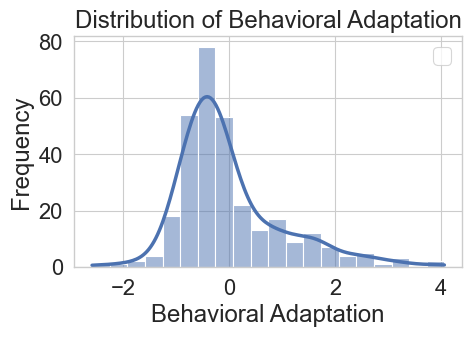

In [8]:
# histogram of Behavioral Adaptation
plt.figure(figsize=(5, 3))
sns.histplot(data=trial_level_df.groupby('subID')['behav_adaptation_SCORE_NORMED'].mean(), bins=20, kde=True) 
plt.title('Distribution of Behavioral Adaptation')
plt.xlabel('Behavioral Adaptation')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Plotting

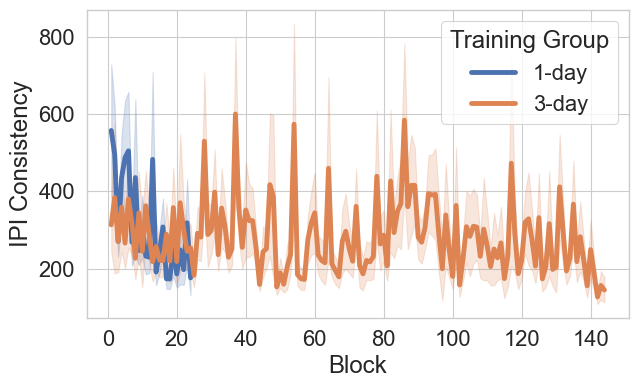

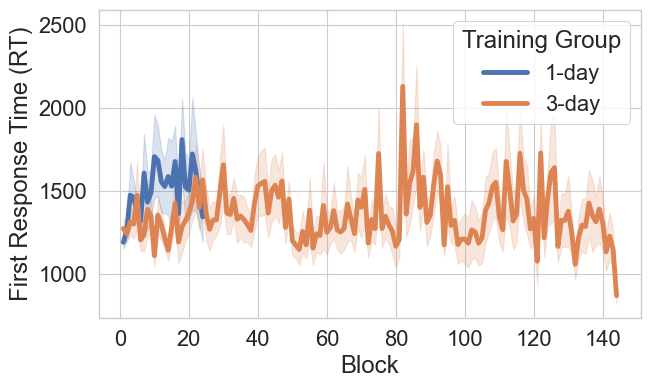

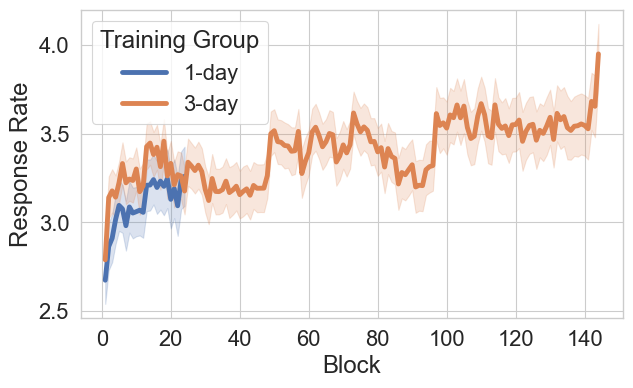

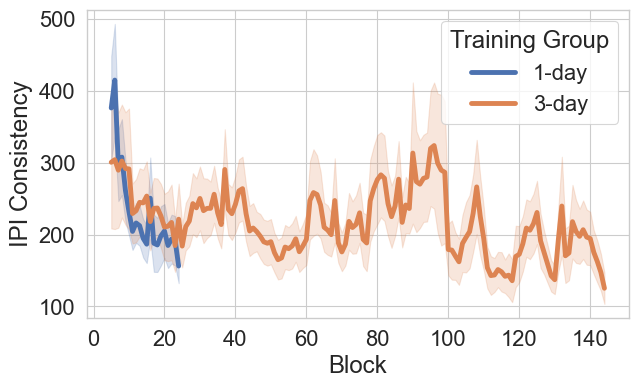

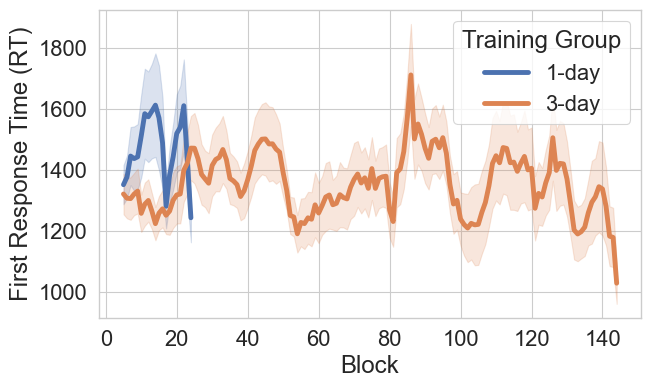

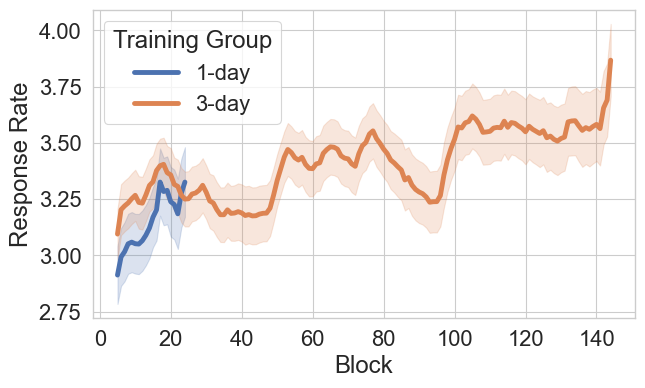

In [244]:
sns.set_context("paper", font_scale=1.8, rc={
    "lines.linewidth": 3.5,
    "lines.markersize": 8
})

# Plot the following variables:
variables_to_plot = ['IPI_abs_diff', 'first_RT', 'resp_rate']

# do x 1000 to have in ms
for var in ['IPI_abs_diff', 'first_RT']:
    trial_level_df[var] = trial_level_df[var] * 1000

y_axis_name_map = {
    'IPI_abs_diff': 'IPI Consistency',
    'first_RT': 'First Response Time (RT)',
    'resp_rate': 'Response Rate'
}
line_col = '#008B8B'

# plot var as a function of trial
for var in variables_to_plot:
    plt.figure(figsize=(7, 4))
    sns.lineplot(data=trial_level_df, x='trial', y=var, hue='group', errorbar='se', color=line_col)
    # sns.lineplot(data=trial_level_df, x='trial', y=var, hue='subID', markers=True, dashes=False)
    # plt.title(f'{var} as a function of trial')
    plt.xlabel('Block')
    # plt.xticks(ticks=sorted(trial_level_df['trial'].unique()))
    plt.ylabel(y_axis_name_map.get(var, var))
    plt.grid(True)
    # make legend title 'Trainig Group':
    plt.legend(title='Training Group')
    plt.show()

trial_level_df_smoothed = trial_level_df.copy()
# plot it smoothed
for var in variables_to_plot:
    plt.figure(figsize=(7, 4))
    # smooth with rolling mean
    trial_level_df_smoothed[f'{var}_smoothed'] = trial_level_df_smoothed.groupby('subID')[var].transform(lambda x: x.rolling(window=5).mean())
    sns.lineplot(data=trial_level_df_smoothed, x='trial', y=f'{var}_smoothed', hue='group', errorbar='se', color=line_col)
    plt.xlabel('Block')
    # plt.xticks(ticks=sorted(trial_level_df['trial'].unique()))
    plt.ylabel(y_axis_name_map.get(var, var))
    plt.grid(True)
    # remove legend title
    plt.legend(title='Training Group')
    plt.show()  
